# 01. EDA — ESS 배터리 수명 예측

- 데이터: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- 목표: Batch 1 / 2 / 3의 특성을 비교하고, 그 결과를 근거로 모델 설계 전략을 세운다.

## 환경 설정

**목적**: 분석에 쓰는 라이브러리, 경로, 그래프 설정, 난수 시드를 한곳에 모아 재현 가능하게 한다.

In [9]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import mat73
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 경고 및 mat73의 string 타입 로딩 메시지 숨김
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.CRITICAL)

# 재현성
SEED = 42
np.random.seed(SEED)

# 경로
DATA_DIR = '../data'
PROC_DIR = '../data/processed'
FIG_DIR = '../results/figures'
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# 그래프 설정 (한글 폰트 포함)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# 표 출력 설정
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 데이터 준비

**목적**: 세 배치의 사이클별 요약(`summary`)을 하나의 DataFrame으로 모은다.
원본 파일은 배치당 2~3GB라 매번 읽기 어려우므로, 추출 결과를 파일로 저장해 이후에는 그 파일만 사용한다.

In [10]:
def load_mat(path):
    """.mat 파일 로더. v7.3(HDF5)은 mat73, 그 이하는 scipy로 읽는다."""
    try:
        data = mat73.loadmat(path)
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
    return data


def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환한다."""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d


def extract_summary(batch, batch_no):
    """배치 내 모든 셀의 summary를 사이클 단위 DataFrame으로 변환한다."""
    records = []
    for i, cell in enumerate(batch):
        s = cell['summary']
        qd = np.array(s['QDischarge'])
        qc = np.array(s['QCharge'])
        ir = np.array(s['IR'])
        tmax = np.array(s['Tmax'])
        tavg = np.array(s['Tavg'])
        tmin = np.array(s['Tmin'])
        ct = np.array(s['chargetime'])

        cycle_life = float(cell['cycle_life'])
        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')

        for c in range(len(qd)):
            records.append({
                'batch': batch_no,
                'cell_id': f'b{batch_no}c{i}',
                'cycle': c + 1,
                'cycle_life': cycle_life,
                'charging_policy': policy,
                'QD': qd[c],
                'QC': qc[c],
                'IR': ir[c],
                'Tmax': tmax[c],
                'Tavg': tavg[c],
                'Tmin': tmin[c],
                'chargetime': ct[c],
            })
    return pd.DataFrame(records)

In [11]:
FILES = {
    1: '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    2: '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    3: '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

dfs = []
for b, fname in FILES.items():
    print(f'Batch {b} 로딩 중...')
    mat = load_mat(os.path.join(DATA_DIR, fname))
    batch = to_list_of_dicts(mat['batch'])
    dfs.append(extract_summary(batch, b))
    del mat, batch

df = pd.concat(dfs, ignore_index=True)
df.to_parquet(os.path.join(PROC_DIR, 'summary.parquet'))

print(df.shape)
print(df.groupby('batch')['cell_id'].nunique())

Batch 1 로딩 중...
Batch 2 로딩 중...
Batch 3 로딩 중...
(116722, 12)
batch
1    46
2    47
3    46
Name: cell_id, dtype: int64


**결과 해석**
- 세 배치를 합친 summary는 116,722행(사이클 단위), 12열이다.
- 셀 수는 Batch 1 46개, Batch 2 47개, Batch 3 46개로 총 139개다.
- 추출 결과를 `data/processed/summary.parquet`으로 저장했다. 이후 분석은 이 파일에서 시작한다.

In [12]:
df = pd.read_parquet(os.path.join(PROC_DIR, 'summary.parquet'))
df.head()

,batch,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,1,b1c0,1,1190.0,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,b1c0,2,1190.0,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,1,b1c0,3,1190.0,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,1,b1c0,4,1190.0,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,1,b1c0,5,1190.0,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


## Q1. Cycle Life 분포는 어떻게 생겼는가?

**목적**: 학습 배치(Batch 1)와 테스트 배치(Batch 2, 3)의 수명 분포를 비교한다.
- 분포의 범위와 형태는 배치마다 같은가
- 장수명(>1,000) / 단수명(<500) 셀의 비율은 어떤가
- 유독 짧거나 값이 이상한 셀이 있는가

In [13]:
cells = df.drop_duplicates('cell_id')[['batch', 'cell_id', 'cycle_life', 'charging_policy']].reset_index(drop=True)

print('수명 값이 없는 셀 수')
print(cells[cells['cycle_life'].isna()].groupby('batch').size())

cells.groupby('batch')['cycle_life'].describe().round(1)

수명 값이 없는 셀 수
batch
2    8
3    2
dtype: int64


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
1,46.0,844.7,184.6,534.0,703.2,858.5,914.2,1227.0
2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


**결과 해석 — 기술통계**

- **수명 값이 없는 셀이 있다.** Batch 2에서 8개, Batch 3에서 2개. 어떤 셀인지는 아래에서 확인한다.
- **세 배치의 수명 수준이 다르다.** 중앙값이 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5다.
- **Batch 2는 한쪽으로 치우친 분포다.** 75% 지점이 508.5인데 최댓값은 1,186이고, 평균(565.7)이 중앙값(472)보다 크다. 대부분의 셀이 400~500대에 몰려 있고 일부만 멀리 떨어져 있다.
- **Batch 2의 대부분은 Batch 1의 범위 밖이다.** Batch 1의 최솟값은 534인데, Batch 2는 75% 지점이 508.5다. Batch 2 셀의 4분의 3 이상이 Batch 1에서 가장 짧은 셀보다 수명이 짧다.

**시사점**: Batch 1로 학습해 Batch 2를 평가하면, 모델은 학습 때 본 적 없는 짧은 수명 구간을 예측해야 한다.

In [14]:
cells[cells['cycle_life'].isna()]

,batch,cell_id,cycle_life,charging_policy
68,2,b2c22,NaN,VarCharge-2C-100cycles
69,2,b2c23,NaN,VarCharge-4C-100cycles
81,2,b2c35,NaN,VarCharge-6C-100cycles
82,2,b2c36,NaN,VarCharge-8C-100cycles
83,2,b2c37,NaN,3.6C(80%)-3.6C(SLOWCYCLE
84,2,b2c38,NaN,4.8C(80%)-4.8C(SLOWCYCLE
85,2,b2c39,NaN,3.6C(9%)-5C(SLOWCYCLE
86,2,b2c40,NaN,5.2C(58%)-4C(SLOWCYCLE
116,3,b3c23,NaN,4.8C(80%)-4.8C-newstructure
125,3,b3c32,NaN,4.8C(80%)-4.8C-newstructure


**결과 해석 — 수명 값이 없는 셀**

- **Batch 2의 8셀은 이름부터 다른 실험이다.** 충전 정책이 `VarCharge-...` (4셀)과 `...(SLOWCYCLE` (4셀)로 표기되어 있다. 다른 셀들의 정책 표기(`C1(Q1%)-C2`)와 형식이 다르다.
- **Batch 3의 2셀은 정책 표기가 정상이다.** 둘 다 `4.8C(80%)-4.8C-newstructure`로, 수명 값만 비어 있다. 왜 비어 있는지는 이 표만으로는 알 수 없다.

**결정**: 수명 값이 없는 10셀은 타깃이 없어 수명 예측의 학습·평가에 쓸 수 없으므로 분석 대상에서 제외한다.
Batch 3의 2셀이 왜 비어 있는지는 열화 곡선(Q2)에서 확인한다.

In [17]:
cells['newstructure'] = cells['charging_policy'].str.contains('newstructure')
cells.groupby(['batch', 'newstructure']).size()

batch  newstructure
1      False           46
2      False           38
       True             9
3      True            46
dtype: int64

**결과 해석 — `newstructure` 표기**

- Batch 1은 전부 표기가 없고, Batch 3은 전부 `newstructure`다.
- **Batch 2에는 두 부류가 섞여 있다**: 표기 없는 38셀과 `newstructure` 9셀.
- 이 표기가 무엇을 의미하는지는 데이터에 설명이 없다. 다만 Batch 2의 9셀이 Batch 3과 같은 표기를 공유하므로, Batch 2를 하나의 균일한 집단으로 보기 전에 두 부류의 수명이 같은지 확인할 필요가 있다.

In [18]:
cells.dropna(subset=['cycle_life']).groupby(['batch', 'newstructure'])['cycle_life'].describe().round(1)

count    mean    std    min    25%     50%     75%     max
batch newstructure                                                            
1     False          46.0   844.7  184.6  534.0  703.2   858.5   914.2  1227.0
2     False          30.0   453.0   34.8  392.0  425.2   451.0   476.2   514.0
      True            9.0   941.6  153.6  777.0  809.0   904.0  1029.0  1186.0
3     True           44.0  1059.7  313.9  541.0  828.0  1005.5  1155.2  1935.0

**결과 해석 — Batch 2 안의 두 집단**

- **Batch 2의 두 부류는 수명 범위가 겹치지 않는다.** 표기 없는 30셀은 392~514, `newstructure` 9셀은 777~1,186이다.
- **표기 없는 30셀은 수명이 매우 균일하다.** 표준편차가 34.8로, Batch 1(184.6)이나 Batch 3(313.9)보다 훨씬 작다.
- **`newstructure` 9셀은 Batch 3과 수준이 비슷하다.** 중앙값이 904로 Batch 3(1,005.5)에 가깝고, Batch 2의 나머지 셀(451)과는 2배 차이가 난다.
- Batch 2 전체 통계에서 평균(565.7)이 중앙값(472)보다 컸던 것은 한쪽으로 치우친 분포여서가 아니라, **성격이 다른 두 집단이 섞여 있었기 때문**이다.

**시사점**
- Batch 2를 하나의 집단으로 평가하면 두 집단의 결과가 섞여 해석이 어렵다. 테스트 성능은 Batch 2 전체와 함께 **두 집단으로 나눠서** 본다.
- Batch 1의 최소 수명은 534인데, Batch 2의 표기 없는 30셀은 최대가 514다. 이 30셀은 **전부 Batch 1의 수명 범위 밖**에 있다.

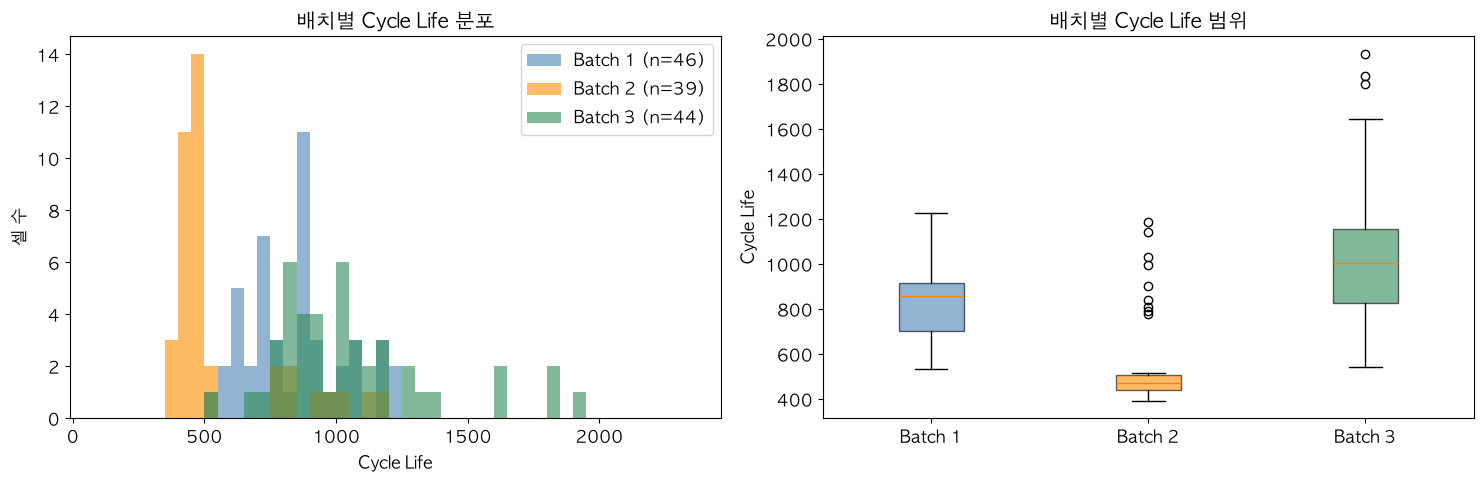

In [15]:
colors = {1: 'steelblue', 2: 'darkorange', 3: 'seagreen'}
bins = np.arange(100, 2400, 50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for b in [1, 2, 3]:
    life = cells.loc[cells['batch'] == b, 'cycle_life'].dropna()
    axes[0].hist(life, bins=bins, alpha=0.6, color=colors[b], label=f'Batch {b} (n={len(life)})')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('셀 수')
axes[0].set_title('배치별 Cycle Life 분포')
axes[0].legend()

data = [cells.loc[cells['batch'] == b, 'cycle_life'].dropna() for b in [1, 2, 3]]
bp = axes[1].boxplot(data, tick_labels=['Batch 1', 'Batch 2', 'Batch 3'], patch_artist=True)
for patch, b in zip(bp['boxes'], [1, 2, 3]):
    patch.set(facecolor=colors[b], alpha=0.6)
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('배치별 Cycle Life 범위')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q1_cycle_life.png'), dpi=150)
plt.show()

**결과 해석 — 분포 그래프**

- **Batch 1과 Batch 2는 거의 겹치지 않는다.** Batch 2의 대부분은 350~550 구간에 몰려 있고, Batch 1은 그 오른쪽인 534부터 시작한다.
- **박스플롯이 Batch 2의 이상치로 표시한 9개 점은 이상치가 아니다.** 앞에서 확인한 `newstructure` 9셀(777~1,186)과 일치한다. 값이 튀는 개별 셀이 아니라 성격이 다른 집단이다.
- **Batch 3은 범위가 가장 넓다.** 541~1,935에 걸쳐 있고, 1,600 이상인 셀이 일부 있어 오른쪽 꼬리가 길다.
- 세 배치 모두 Batch 1과 겹치는 구간(약 550~1,200)에 셀이 있지만, 그 밖의 구간은 Batch 2(짧은 쪽)와 Batch 3(긴 쪽)에만 있다.

**시사점**: 학습 배치의 수명 범위(534~1,227)보다 테스트 배치의 범위가 양쪽으로 더 넓다. Batch 2는 짧은 쪽으로, Batch 3은 긴 쪽으로 학습 범위를 벗어난다.

In [19]:
ratio = cells.dropna(subset=['cycle_life']).groupby('batch')['cycle_life'].agg(
    셀수='size',
    단수명_500미만=lambda x: (x < 500).sum(),
    장수명_1000초과=lambda x: (x > 1000).sum(),
    분류기준_550미만=lambda x: (x < 550).sum(),
)
ratio

,셀수,단수명_500미만,장수명_1000초과,분류기준_550미만
batch,,,,
1,46,0,10,1
2,39,28,3,30
3,44,0,23,1


**결과 해석 — 장수명/단수명 비율**

- **단수명(<500) 셀은 Batch 2에만 있다.** Batch 2는 39셀 중 28셀이 단수명이고, Batch 1과 Batch 3에는 한 개도 없다.
- **장수명(>1,000) 셀은 Batch 3에 가장 많다.** Batch 3은 44셀 중 23셀, Batch 1은 46셀 중 10셀, Batch 2는 39셀 중 3셀이다.
- **분류 기준(550사이클)으로 나누면 Batch 1에는 단수명 클래스가 1개뿐이다.** 46셀 중 45셀이 장수명 클래스다. 반면 Batch 2는 39셀 중 30셀이 단수명 클래스다.

**시사점**: Batch 1로 분류 모델을 학습하면 단수명 클래스의 표본이 1개라 그 클래스의 특징을 배울 수 없다. 그런데 테스트 배치(Batch 2)는 대부분이 단수명 클래스다. 과제 조건(Batch 1 학습 → Batch 2 평가)에서는 **Classification이 성립하지 않는다.**

### Q1 결론

**확인한 사실**
1. 수명 값이 없는 셀이 10개 있다. Batch 2의 8셀은 다른 실험(`VarCharge`, `SLOWCYCLE`)이고, Batch 3의 2셀은 원인 미확인이다.
2. 세 배치의 수명 분포가 다르다. 중앙값이 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5다.
3. Batch 2는 두 집단의 혼합이다. 표기 없는 30셀(392~514)과 `newstructure` 9셀(777~1,186)의 수명 범위가 겹치지 않는다.
4. Batch 2의 표기 없는 30셀은 전부 Batch 1의 최소 수명(534)보다 짧다.
5. 분류 기준 550사이클 미만인 셀이 Batch 1에는 1개뿐이다.

**모델 설계에 주는 시사점**
- **Regression을 선택한다.** Batch 1에는 단수명 클래스가 1개뿐이라 분류 모델을 학습할 수 없다. (사실 5)
- **학습 범위 밖을 예측해야 하는 문제다.** 테스트 셀의 다수가 학습 배치의 수명 범위 밖에 있으므로, 모델을 고를 때 학습 범위 밖에서도 예측이 가능한지를 기준에 넣는다. (사실 2, 4)
- **테스트 성능은 Batch 2의 두 집단을 나눠서 본다.** (사실 3)

**남은 질문**
- Batch 3의 2셀은 왜 수명 값이 없는가 → Q2에서 열화 곡선으로 확인
- Batch 1의 `cycle_life` 46개는 모두 실제 EOL 도달 시점인가 → Q2에서 확인
- `newstructure`는 무엇을 의미하며, Batch 2의 두 집단은 왜 수명이 다른가

> **수정 (Q2-3 이후)**: Batch 1의 10셀이 EOL 미도달로 확인되어 제외했다. Batch 1의 통계는 36셀 기준으로 중앙값 772.5, 범위 534~1,074다. Q1의 결론(Regression 선택, 학습 범위 밖 예측, Batch 2 두 집단)은 그대로 유지된다.

## Q2. 열화 곡선: 방전 용량은 어떻게 감소하는가?

**목적**: 사이클이 진행됨에 따라 방전 용량(QD)이 어떻게 줄어드는지 배치별로 확인한다.
- 열화 속도는 일정한가, 중간에 가속되는가
- 급격한 열화가 시작되는 지점(knee point)은 어디인가
- 모델이 사용할 초기 100사이클 구간에서 셀 간 차이가 보이는가
- (Q1의 남은 질문) `cycle_life` 값은 실제 EOL 도달 시점과 일치하는가

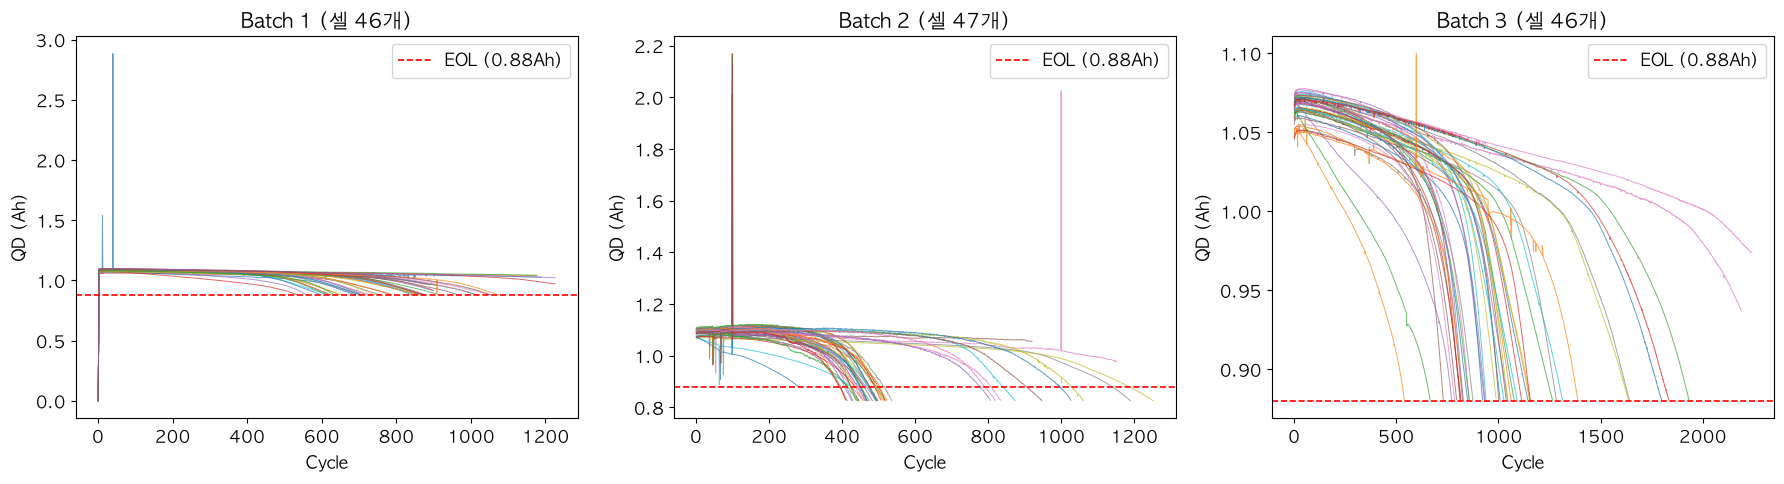

In [20]:
EOL = 0.88   # 공칭 용량 1.1Ah의 80%

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, b in zip(axes, [1, 2, 3]):
    sub = df[df['batch'] == b]
    for cid, g in sub.groupby('cell_id'):
        ax.plot(g['cycle'], g['QD'], linewidth=0.7, alpha=0.7)
    ax.axhline(EOL, color='red', linestyle='--', linewidth=1.2, label='EOL (0.88Ah)')
    ax.set_title(f'Batch {b} (셀 {sub["cell_id"].nunique()}개)')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QD (Ah)')
    ax.legend()

plt.tight_layout()
plt.show()

**결과 해석 — 원본 열화 곡선**

- **측정 오류로 보이는 값이 있다.** Batch 1에는 0Ah와 1.5~2.9Ah, Batch 2에는 2Ah 이상의 값이 있다. 공칭 용량 1.1Ah인 셀에서 나올 수 없는 값이므로 열화 분석 전에 걸러야 한다.
- **곡선이 끝나는 높이가 배치마다 다르다.** Batch 3은 0.88Ah 부근에서 끝나고, Batch 2는 그 아래(약 0.83Ah)까지 내려간 뒤 끝난다. 시험을 멈춘 기준이 배치마다 달랐던 것으로 보인다.
- **EOL 선에 닿지 않고 끝나는 곡선이 있다.** Batch 3에서 2,000사이클을 넘긴 2개 곡선은 0.94~0.97Ah에서 끝난다. Batch 1과 Batch 2에도 1.0Ah 부근에서 끝나는 곡선이 보인다.

**다음 단계**: 이상값을 걸러낸 뒤 다시 그리고, 셀별로 마지막 방전 용량을 확인해 EOL 도달 여부를 판정한다.

**이상값 범위 탐색**

원본 그래프에서 본 튀는 값이 정상 값과 얼마나 떨어져 있는지 확인한다. 정상 값과 이상값 사이에 빈 구간이 있으면, 그 구간을 기준으로 삼을 수 있다.

In [22]:
print(df['QD'].describe())
print(df['QD'].quantile([0, 0.0001, 0.001, 0.01, 0.5, 0.99, 0.999, 0.9999, 1]))

count    116722.000000
mean          1.038783
std           0.055874
min           0.000000
25%           1.022585
50%           1.053118
75%           1.071628
max           2.884085
Name: QD, dtype: float64
0.0000    0.000000
0.0001    0.000000
0.0010    0.829123
0.0100    0.881012
0.5000    1.053118
0.9900    1.108376
0.9990    1.118073
0.9999    1.694559
1.0000    2.884085
Name: QD, dtype: float64


In [23]:
print('QD < 0.8 인 값들:')
print(df.loc[df['QD'] < 0.8, 'QD'].sort_values().round(3).tolist())
print('QD > 1.15 인 값들:')
print(df.loc[df['QD'] > 1.15, 'QD'].sort_values().round(3).tolist())

QD < 0.8 인 값들:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
QD > 1.15 인 값들:
[1.539, 2.013, 2.026, 2.061, 2.127, 2.15, 2.162, 2.162, 2.165, 2.167, 2.168, 2.169, 2.884]


**QD가 0인 행의 위치 확인**

0.0인 값이 46개로 Batch 1의 셀 수와 같다. 무작위로 흩어진 오류인지, 특정 배치와 사이클에 몰려 있는지 확인한다.

In [24]:
df[df['QD'] == 0].groupby(['batch', 'cycle']).size()

batch  cycle
1      1        46
dtype: int64

### Q2-1. 이상값 기준과 EOL 도달 여부

**목적**: 측정 오류로 보이는 QD 값을 걸러내고, 각 셀이 실제로 EOL(0.88Ah)에 도달했는지 마지막 방전 용량으로 판정한다.

**기준을 정한 과정**

1. 원본 열화 곡선에서 0Ah 부근과 2Ah 이상으로 튀는 값을 확인했다. 공칭 용량이 1.1Ah인 셀에서 나올 수 없는 값이다.
2. QD 전체 분포를 확인했다.
   - 0.8Ah 미만인 값은 46개이고 전부 0.0이다. 그다음으로 작은 값은 약 0.82Ah다.
   - 1.15Ah 초과인 값은 13개이고 가장 작은 것이 1.539Ah다. 정상 값은 약 1.12Ah에서 끝난다.
3. QD가 0인 46개 행은 전부 Batch 1의 `cycle` 1이다. 무작위 오류가 아니라 Batch 1의 첫 사이클 기록이 비어 있는 구조적 특징이다.

**정상 범위: 0.8Ah ≤ QD ≤ 1.15Ah**

- 0~0.82Ah와 1.12~1.54Ah 구간에 값이 하나도 없다. 기준을 이 구간 안 어디에 두어도 걸러지는 행은 같은 59개(0.0인 46개, 1.5Ah 이상인 13개)다.
- 하한 0.8Ah: Batch 2는 0.88Ah 아래 약 0.83Ah까지 열화가 진행된 뒤 시험이 끝난다. 이 구간은 정상 데이터이므로 남겨야 한다.
- 상한 1.15Ah: 초기 방전 용량이 약 1.05~1.11Ah이므로 그보다 조금 위에 두었다.
- 스크래치 노트북의 기준(공칭 용량의 ±20%, 0.864~1.296Ah)은 쓰지 않았다. Batch 1만 볼 때는 문제가 없지만, Batch 2에 적용하면 0.83~0.864Ah 구간의 정상 열화 데이터가 잘려 나간다.

**EOL 도달 판정**: 이상값을 제외한 마지막 QD가 0.885Ah 이하이면 도달한 것으로 본다. 0.88Ah 바로 위에서 시험이 끝난 셀을 포함하기 위해 0.005Ah의 여유를 두었다.

In [25]:
QD_MIN, QD_MAX = 0.8, 1.15   # 직접 정한 정상 범위

df['qd_ok'] = df['QD'].between(QD_MIN, QD_MAX)
print('범위 밖 행 수:', (~df['qd_ok']).sum(), '/', len(df))
print(df[~df['qd_ok']].groupby('batch').size())

last = (df[df['qd_ok']]
        .groupby('cell_id')
        .agg(n_cycles=('cycle', 'max'), qd_last=('QD', 'last'))
        .reset_index())
cells2 = cells.merge(last, on='cell_id')
cells2['reached_eol'] = cells2['qd_last'] <= 0.885

cells2.groupby(['batch', 'reached_eol']).size()

범위 밖 행 수: 59 / 116722
batch
1    48
2    11
dtype: int64


batch  reached_eol
1      False          10
       True           36
2      False           4
       True           43
3      False           2
       True           44
dtype: int64

**결과 해석 — 이상값과 EOL 도달 여부**

- 범위 밖 행은 59개(전체의 0.05%)다. Batch 1의 48개는 첫 사이클의 0.0 값 46개와 스파이크 2개이고, Batch 2의 11개는 2Ah 이상의 스파이크다. Batch 3에는 없다.
- **EOL(0.88Ah)에 도달하지 않은 셀이 16개 있다.** Batch 1 10셀, Batch 2 4셀, Batch 3 2셀.
- **Batch 1의 10셀은 `cycle_life` 값이 있는데도 EOL에 도달하지 않았다.** Q1에서 Batch 1은 46셀 모두 수명 값이 있었다. 이 10셀의 `cycle_life`가 무엇을 뜻하는지 확인이 필요하다.

### Q2-2. EOL에 도달하지 않은 셀 확인

**목적**: EOL 미도달로 판정된 16셀이 어떤 셀인지 확인한다.
- Batch 1의 10셀은 `cycle_life` 값이 있는데 왜 EOL에 도달하지 않았는가
- Batch 2, 3의 미도달 셀은 Q1에서 수명 값이 없던 셀과 같은가

In [26]:
cols = ['batch', 'cell_id', 'charging_policy', 'cycle_life', 'n_cycles', 'qd_last']
cells2[~cells2['reached_eol']][cols].round(3)

,batch,cell_id,charging_policy,cycle_life,n_cycles,qd_last
0,1,b1c0,3.6C(80%)-3.6C,1190.0,1189,1.026
1,1,b1c1,3.6C(80%)-3.6C,1179.0,1178,1.038
2,1,b1c2,3.6C(80%)-3.6C,1177.0,1176,1.043
3,1,b1c3,4C(80%)-4C,1226.0,1225,0.971
4,1,b1c4,4C(80%)-4C,1227.0,1226,1.022
8,1,b1c8,5.4C(40%)-3.6C,879.0,878,0.969
10,1,b1c10,5.4C(50%)-3C,906.0,905,0.961
12,1,b1c12,5.4C(50%)-3.6C,902.0,901,0.913
13,1,b1c13,5.4C(50%)-3.6C,897.0,896,0.923
22,1,b1c22,6C(30%)-3.6C,891.0,890,0.963


### Q2-3. 분석 대상 셀 확정

**목적**: 수명 예측에 쓸 수 있는 셀을 확정하고, Q1의 배치별 통계를 다시 계산한다.

**선별 조건**: 수명 값이 있고(`cycle_life` 결측 아님) EOL에 도달한 셀(`reached_eol`).
- EOL 도달 여부만으로는 부족하다. Batch 2의 다른 실험 셀 8개 중 4개는 EOL에 도달했지만 수명 값이 없다.

In [27]:
cells2['use'] = cells2['reached_eol'] & cells2['cycle_life'].notna()
print(cells2.groupby('batch')['use'].agg(['sum', 'size']))

cells2[cells2['use']].groupby('batch')['cycle_life'].describe().round(1)

       sum  size
batch           
1       36    46
2       39    47
3       44    46


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
1,36.0,788.4,148.7,534.0,681.0,772.5,871.5,1074.0
2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


**결과 해석 — 분석 대상 셀 확정**

- 분석 대상은 **Batch 1 36셀, Batch 2 39셀, Batch 3 44셀**, 총 119셀이다. 전체 139셀 중 20셀을 제외했다.
- Batch 2와 Batch 3의 통계는 Q1과 같다. 제외된 셀은 원래 수명 값이 없어 Q1 통계에 포함되지 않았기 때문이다.
- **Batch 1의 통계는 달라졌다.** 중앙값이 858.5에서 772.5로, 최댓값이 1,227에서 1,074로 내려갔다. 기록상 수명이 길었던 셀 다수가 중도절단된 값이었다.
- Batch 1의 최솟값은 534로 변함없다. Batch 2 일반 30셀(최대 514)이 전부 Batch 1의 수명 범위 밖이라는 Q1의 결론은 유지된다.

**시사점**
- 학습 데이터의 수명 범위는 **534~1,074**다. Q1에서 본 것보다 위쪽이 좁아졌다.
- Batch 3은 최대 1,935까지 있으므로, Batch 3에서는 긴 쪽으로도 학습 범위를 벗어나는 셀이 더 많아진다.
- 학습 셀이 36개로 적다. 모델 복잡도를 정할 때 고려해야 한다.

### Q2-4. 정제 후 열화 곡선

**목적**: 이상값과 분석 대상이 아닌 셀을 제외한 뒤 열화 곡선을 다시 그려, Q2의 원래 질문에 답한다.
- 열화 속도는 일정한가, 중간에 가속되는가
- 모델이 사용할 초기 100사이클 구간에서 셀 간 차이가 보이는가

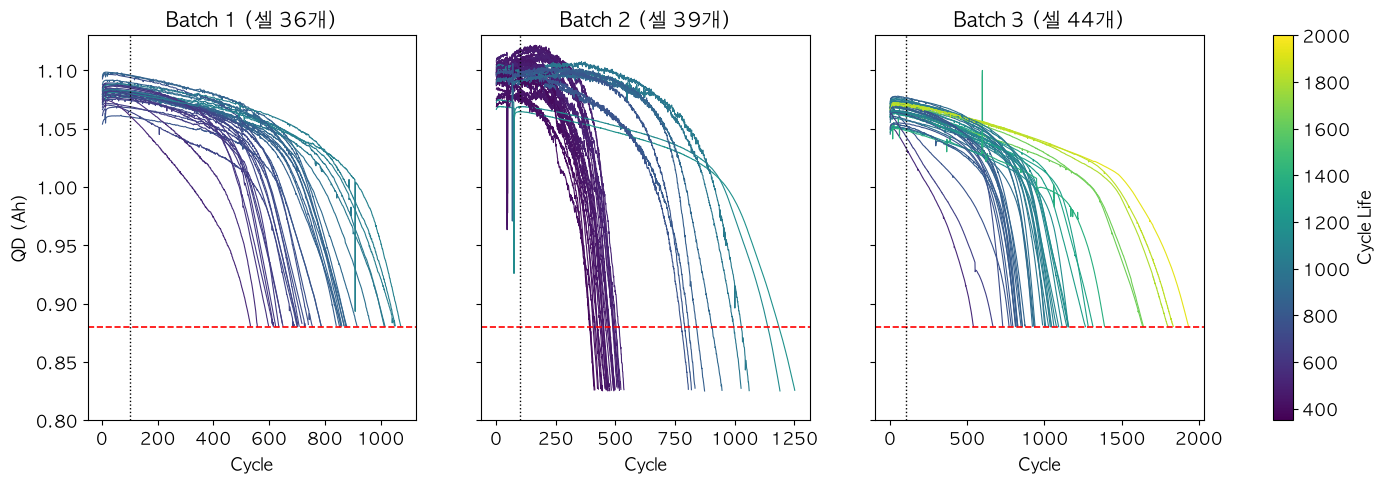

In [28]:
use_ids = cells2.loc[cells2['use'], 'cell_id']
d = df[df['cell_id'].isin(use_ids) & df['qd_ok']]

norm = plt.Normalize(350, 2000)
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, b in zip(axes, [1, 2, 3]):
    sub = d[d['batch'] == b]
    for cid, g in sub.groupby('cell_id'):
        ax.plot(g['cycle'], g['QD'], color=cmap(norm(g['cycle_life'].iloc[0])), linewidth=0.8)
    ax.axhline(EOL, color='red', linestyle='--', linewidth=1.2)
    ax.axvline(100, color='black', linestyle=':', linewidth=1)
    ax.set_title(f'Batch {b} (셀 {sub["cell_id"].nunique()}개)')
    ax.set_xlabel('Cycle')
    ax.set_ylim(0.8, 1.13)
axes[0].set_ylabel('QD (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='Cycle Life')
plt.savefig(os.path.join(FIG_DIR, 'q2_fade_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — 정제 후 열화 곡선**

- **열화 속도는 일정하지 않다.** 세 배치 모두 초반에는 완만하게 줄다가, 특정 지점부터 급격히 꺾여 EOL에 도달한다. 직선이 아니라 무릎(knee) 모양이다.
- **초기 100사이클에서는 수명이 긴 셀과 짧은 셀이 구분되지 않는다.** 곡선들이 한 덩어리로 겹쳐 있고, 갈라지는 것은 100사이클을 한참 지난 뒤다.
- **배치마다 초기 용량 수준이 다르다.** Batch 2가 가장 높고(약 1.07~1.11Ah) Batch 3이 가장 낮다(약 1.05~1.08Ah).
- Batch 2의 일부 셀은 초반 100~200사이클에서 용량이 오히려 증가한다.
- 정상 범위 안에 있는 스파이크가 일부 남아 있다(Batch 2의 사이클 50~80 부근, Batch 3의 사이클 600 부근).

**시사점**
- 모델이 쓸 수 있는 초기 100사이클 구간에서, 방전 용량 값 자체는 수명을 구분하는 신호가 되기 어렵다.
- 배치마다 초기 용량 수준이 다르므로, 용량의 절댓값을 피처로 쓰면 배치 차이가 섞여 들어갈 수 있다.

### Q2-5. 정상 범위 안의 스파이크 처리

**목적**: Q2-4 그래프에서 정상 범위(0.8~1.15Ah) 안에 남아 있는 스파이크를 찾아낸다.
고정 범위로는 잡을 수 없으므로, 각 셀에서 주변 사이클의 중앙값과 비교해 벗어난 정도를 계산한다.
먼저 벗어난 정도의 분포를 보고 기준을 정한다.

**Q2-1의 절대 범위와의 관계**: 절대 범위는 물리적으로 나올 수 없는 값(0.0, 1.5Ah 이상)을 걸러내지만, 값 하나만 보기 때문에 범위 안에서 앞뒤 흐름과 어긋나는 값은 잡지 못한다. 예를 들어 0.95Ah는 수명 후반에는 정상 값이지만 초반에는 스파이크다. 이 단계는 절대 범위를 대체하는 것이 아니라, 그 뒤에 적용하는 두 번째 필터다.

In [30]:
d = d.sort_values(['cell_id', 'cycle']).copy()
d['qd_med'] = d.groupby('cell_id')['QD'].transform(
    lambda x: x.rolling(11, center=True, min_periods=1).median())
d['qd_dev'] = (d['QD'] - d['qd_med']).abs()

print(d['qd_dev'].quantile([0.5, 0.9, 0.99, 0.999, 0.9999, 1]).round(4))
print()
print('편차가 큰 상위 20개 행')
print(d.nlargest(20, 'qd_dev')[['batch', 'cell_id', 'cycle', 'QD', 'qd_med', 'qd_dev']].round(4))

0.5000    0.0000
0.9000    0.0007
0.9900    0.0025
0.9990    0.0056
0.9999    0.0640
1.0000    0.1403
Name: qd_dev, dtype: float64

편차가 큰 상위 20개 행
        batch cell_id  cycle      QD  qd_med  qd_dev
57104       2   b2c33     75  0.9258  1.0661  0.1403
45230       2   b2c11     46  0.9633  1.1011  0.1378
42967       2    b2c8     68  0.9707  1.0891  0.1184
6902        1    b1c5    909  0.8933  1.0040  0.1107
44712       2   b2c10     47  0.9990  1.1081  0.1091
41287       2    b2c5     48  0.9776  1.0832  0.1056
49928       2   b2c21     48  0.9943  1.0997  0.1053
39866       2    b2c2     47  0.9673  1.0696  0.1024
64233       2   b2c45     69  1.0218  1.0992  0.0774
105836      3   b3c37    598  1.0998  1.0310  0.0688
105835      3   b3c37    597  1.0937  1.0310  0.0628
63230       2   b2c43   1001  0.8961  0.9151  0.0190
48055       2   b2c17     53  1.1099  1.0944  0.0156
62778       2   b2c43    549  1.0736  1.0864  0.0128
106302      3   b3c37   1064  0.9825  0.9950  0.0125
42163

In [36]:
DEV_MAX = 0.04   # 직접 정한 기준

d['spike'] = d['qd_dev'] > DEV_MAX
print('스파이크 행 수:', d['spike'].sum())
print(d[d['spike']].groupby('batch').size())
print('초기 100사이클 안:', (d['spike'] & (d['cycle'] <= 100)).sum())

d_clean = d[~d['spike']].copy()

스파이크 행 수: 11
batch
1    1
2    8
3    2
dtype: int64
초기 100사이클 안: 8


**결과 해석 — 스파이크 제거**

- 스파이크로 판정된 행은 **11개**다. Batch 1 1개, Batch 2 8개, Batch 3 2개.
- 그중 **8개가 초기 100사이클 안**에 있고, 전부 Batch 2다(사이클 46~75). 그대로 두었다면 초기 사이클로 만드는 피처에 직접 영향을 주었을 값이다.
- 제거 후 데이터(`d_clean`)는 절대 범위와 주변 값 비교, 두 단계의 필터를 모두 거친 상태다.

**기준**: 주변 11사이클 중앙값과의 차이가 0.04Ah를 넘는 행을 스파이크로 본다.
- 편차 0.019~0.063Ah 구간에 값이 없으므로, 기준을 이 안 어디에 두어도 제외되는 행은 같은 11개다.
- 편차 0.02Ah 이하인 행은 수명 끝의 급격한 열화 구간이므로 정상 데이터로 남긴다.

**정제 요약**: 전체 116,722행 중 절대 범위로 59행, 주변 값 비교로 11행을 제외했다.

### Q2-6. 초기 100사이클의 용량 변화

**목적**: Q2-4 그래프에서 본 "초기 100사이클에서는 셀 간 차이가 보이지 않는다"를 숫자로 확인한다.
- 2번째 사이클 대비 100번째 사이클의 방전 용량은 얼마나 변했는가
- 그 변화량은 수명과 관련이 있는가

Batch 1은 첫 사이클 기록이 비어 있으므로, 세 배치에 같은 구간을 적용하기 위해 사이클 2~100을 사용한다.

In [37]:
early = d_clean[d_clean['cycle'].between(2, 100)]
chg = early.groupby('cell_id').agg(
    batch=('batch', 'first'),
    cycle_life=('cycle_life', 'first'),
    qd_first=('QD', 'first'),
    qd_100=('QD', 'last'),
).reset_index()
chg['qd_change'] = chg['qd_100'] - chg['qd_first']

print(chg.groupby('batch')['qd_change'].describe().round(4))
print()
print('용량이 줄지 않은 셀의 비율')
print(chg.groupby('batch')['qd_change'].apply(lambda x: (x >= 0).mean()).round(2))
print()
print('qd_change와 cycle_life의 상관계수')
print(chg.groupby('batch').apply(lambda g: g['qd_change'].corr(g['cycle_life'])).round(2))

       count    mean     std     min     25%     50%     75%     max
batch                                                               
1       36.0  0.0020  0.0032 -0.0114  0.0017  0.0024  0.0033  0.0066
2       39.0  0.0021  0.0067 -0.0229 -0.0010  0.0022  0.0069  0.0128
3       44.0  0.0002  0.0049 -0.0188  0.0004  0.0014  0.0023  0.0038

용량이 줄지 않은 셀의 비율
batch
1    0.89
2    0.64
3    0.84
Name: qd_change, dtype: float64

qd_change와 cycle_life의 상관계수
batch
1    0.47
2   -0.20
3    0.28
dtype: float64


**결과 해석 — 초기 100사이클의 용량 변화**

- **초기 100사이클 동안 방전 용량은 거의 변하지 않는다.** 변화량의 중앙값이 Batch 1 +0.0024Ah, Batch 2 +0.0022Ah, Batch 3 +0.0014Ah다. EOL까지의 감소량(약 0.2Ah)의 1% 수준이고, 정상적인 사이클 간 변동(Q2-5, 99%가 0.0025Ah 이하)과 비슷한 크기다.
- **대부분의 셀은 용량이 줄지도 않았다.** 100사이클 시점의 용량이 2번째 사이클보다 크거나 같은 셀이 Batch 1 89%, Batch 2 64%, Batch 3 84%다.
- **변화량과 수명의 관계는 약하고 배치마다 방향이 다르다.** 상관계수가 Batch 1 +0.47, Batch 2 −0.20, Batch 3 +0.28이다.

**시사점**
- 방전 용량의 크기나 그 변화량은 초기 100사이클 구간에서 수명을 예측하는 신호가 되기 어렵다. 변화 자체가 잡음 수준이다.
- Batch 1에서 보이는 양의 상관(+0.47)을 근거로 이 값을 피처로 쓰면, 관계의 방향이 반대인 Batch 2에서는 오히려 예측을 해칠 수 있다. **학습 배치에서의 상관만으로 피처를 고르면 안 된다.**
- 용량 값이 아닌 다른 신호가 필요하다 → Q3의 ΔQ(V).

### Q2-7. Knee point — 급격한 열화의 시작점

**목적**: Q2-4에서 본 "완만하다가 급격히 꺾이는" 지점이 어디인지 셀별로 구한다.
- knee는 수명의 몇 % 지점에서 나타나는가
- 모델이 사용할 초기 100사이클 안에 knee가 있는 셀이 있는가
- knee 전과 후의 열화 속도는 얼마나 다른가

**방법**: 각 셀의 열화 곡선에서 시작점과 EOL 도달점을 직선으로 잇고, 그 직선에서 가장 멀리 떨어진 점을 knee로 정의한다.
사이클과 용량의 단위가 다르므로 둘 다 0~1로 정규화한 뒤 거리를 계산하고, 잡음의 영향을 줄이기 위해 15사이클 이동 중앙값으로 평활한 곡선을 사용한다.

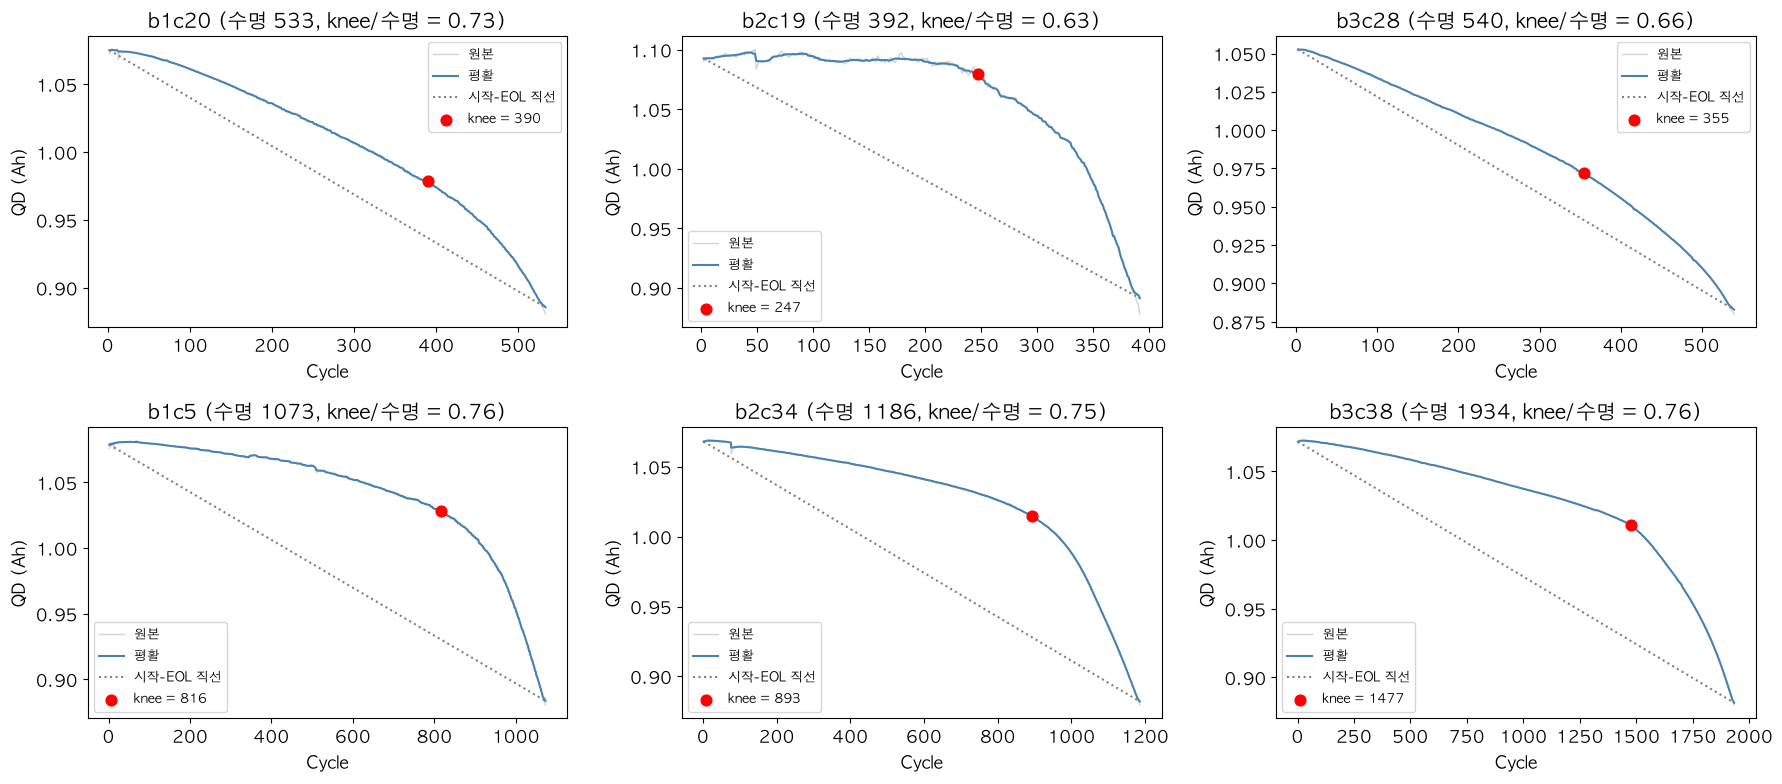

In [38]:
def find_knee(g):
    """한 셀의 (cycle, QD)에서 knee 위치를 찾는다. g는 cycle 순으로 정렬된 DataFrame."""
    k = g['cycle'].values
    q = g['QD'].rolling(15, center=True, min_periods=1).median().values
    x = (k - k[0]) / (k[-1] - k[0])
    y = (q - q[-1]) / (q[0] - q[-1])
    i = int(np.argmax(y - (1 - x)))      # 직선 y = 1 - x 위로 가장 멀리 떨어진 점
    return i, k, q


# EOL 도달 시점까지만 사용 (Batch 2는 0.88Ah 아래까지 기록이 이어지므로 잘라낸다)
dk = d_clean[(d_clean['cycle'] >= 2) & (d_clean['cycle'] <= d_clean['cycle_life'])]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for col, b in enumerate([1, 2, 3]):
    cb = cells2[(cells2['batch'] == b) & cells2['use']].sort_values('cycle_life')
    for row, cid in enumerate([cb['cell_id'].iloc[0], cb['cell_id'].iloc[-1]]):
        g = dk[dk['cell_id'] == cid]
        i, k, q = find_knee(g)
        ax = axes[row, col]
        ax.plot(g['cycle'], g['QD'], color='lightgray', linewidth=1, label='원본')
        ax.plot(k, q, color='steelblue', linewidth=1.5, label='평활')
        ax.plot([k[0], k[-1]], [q[0], q[-1]], color='gray', linestyle=':', label='시작-EOL 직선')
        ax.scatter(k[i], q[i], color='red', s=60, zorder=5, label=f'knee = {k[i]}')
        ax.set_title(f'{cid} (수명 {k[-1]}, knee/수명 = {k[i] / k[-1]:.2f})')
        ax.set_xlabel('Cycle')
        ax.set_ylabel('QD (Ah)')
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q2_knee_examples.png'), dpi=150)
plt.show()

In [39]:
rows = []
for cid, g in dk.groupby('cell_id'):
    i, k, q = find_knee(g)
    rows.append({
        'cell_id': cid,
        'batch': g['batch'].iloc[0],
        'cycle_life': g['cycle_life'].iloc[0],
        'knee': k[i],
        'knee_ratio': k[i] / k[-1],
        'rate_before': (q[0] - q[i]) / (k[i] - k[0]) * 1000,     # mAh/cycle
        'rate_after': (q[i] - q[-1]) / (k[-1] - k[i]) * 1000,
    })
knee = pd.DataFrame(rows)
knee['accel'] = knee['rate_after'] / knee['rate_before']

print(knee.groupby('batch')[['knee_ratio', 'knee', 'rate_before', 'rate_after', 'accel']].median().round(3))
print()
print('knee_ratio 표준편차')
print(knee.groupby('batch')['knee_ratio'].std().round(3))
print()
print('가장 이른 knee (사이클)')
print(knee.groupby('batch')['knee'].min())
print()
print('knee가 100사이클 이내인 셀 수:', (knee['knee'] <= 100).sum())

       knee_ratio   knee  rate_before  rate_after   accel
batch                                                    
1           0.710  550.0        0.070       0.674   9.476
2           0.686  328.0        0.084       1.139  10.984
3           0.759  764.5        0.059       0.568   8.975

knee_ratio 표준편차
batch
1    0.027
2    0.056
3    0.035
Name: knee_ratio, dtype: float64

가장 이른 knee (사이클)
batch
1    390
2    243
3    355
Name: knee, dtype: int64

knee가 100사이클 이내인 셀 수: 0


**결과 해석 — Knee point**

- **knee는 수명의 약 70% 지점에서 나타난다.** `knee_ratio`의 중앙값이 Batch 1 0.71, Batch 2 0.69, Batch 3 0.76이고, 표준편차는 0.03~0.06으로 작다. 수명은 셀마다 크게 달라도 knee의 상대적 위치는 비슷하다.
- **knee 이후 열화 속도는 이전의 약 9~11배다.** 이전에는 사이클당 0.06~0.08mAh, 이후에는 0.57~1.14mAh씩 줄어든다.
- **모델이 볼 수 있는 구간에는 knee가 없다.** 가장 이른 knee가 243사이클이고, 100사이클 이내에 knee가 있는 셀은 0개다.
- Batch 2는 knee 이후 열화 속도(1.14mAh/사이클)가 다른 배치(0.57~0.67)보다 빠르다.
- 예시 그래프에서 수명이 긴 셀은 꺾임이 뚜렷하고, 수명이 짧은 셀(b1c20, b3c28)은 처음부터 꾸준히 감소해 꺾임이 완만하다. 다만 배치당 두 셀만 확인한 관찰이다.

**시사점**
- 수명을 결정하는 급격한 열화는 관측 구간(100사이클) 밖에서 시작된다. 초기 데이터로 수명을 예측한다는 것은, **아직 일어나지 않은 knee의 시점을 그 전의 신호로 맞히는 문제**다.
- 열화 곡선의 겉모습(용량 값)에는 그 신호가 드러나지 않으므로(Q2-6), 곡선 안쪽의 변화를 봐야 한다.

### Q2 결론

**확인한 사실**
1. 원본 데이터에 측정 오류가 있다. 절대 범위(0.8~1.15Ah)로 59행, 주변 값 비교로 11행을 제외했다. 후자 중 8행은 초기 100사이클 안에 있었다.
2. Batch 1의 첫 사이클은 46셀 모두 기록이 비어 있다. 배치 간 사이클 번호가 한 칸 어긋난다.
3. EOL에 도달하지 않은 셀이 있다. Batch 1의 10셀은 `cycle_life`가 수명이 아니라 시험 종료 시점이었다. 분석 대상은 Batch 1 36셀, Batch 2 39셀, Batch 3 44셀이다.
4. 열화는 일정하지 않다. knee는 수명의 약 70% 지점에 있고, 이후 열화가 약 9~11배 빨라진다.
5. 초기 100사이클 안에는 knee가 없고, 그 구간의 용량 변화는 중앙값 +0.001~+0.002Ah로 잡음 수준이다.
6. 초기 용량 변화와 수명의 상관은 Batch 1 +0.47, Batch 2 −0.20으로 방향이 다르다.

**모델 설계에 주는 시사점**
- **학습 데이터는 Batch 1의 36셀이다.** 표본이 작으므로 단순한 모델과 적은 수의 피처가 필요하다. (사실 3)
- **방전 용량의 크기나 변화량은 핵심 피처가 될 수 없다.** (사실 5, 6)
- **피처를 고를 때 Batch 1에서의 상관만 보면 안 된다.** 배치 간에 관계의 방향이 유지되는지 확인해야 한다. (사실 6)
- **피처 계산 전에 두 단계의 정제를 적용한다.** (사실 1)
- 초기 사이클을 기준으로 피처를 만들 때 배치 간 사이클 번호를 맞춘다. (사실 2)

**남은 질문**
- 용량 값에 신호가 없다면, 초기 100사이클의 어떤 신호가 수명을 구분하는가 → Q3